In [29]:
import pandas as pd
import numpy as np
import scipy.stats as st
from sklearn.model_selection import GridSearchCV, LeaveOneOut
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

import os
os.environ["OMP_NUM_THREADS"] = "7"


In [2]:
#read in the exoplanet data
# 'pl_dens'
df = pd.read_csv('exoplanets.csv', comment='#', low_memory=False)
features = df[['pl_rade', 'pl_masse', 'pl_orbper']]

In [3]:
ss_planets = pd.read_csv('Solar_system.csv', usecols=[2,3,4, 6], skiprows=2,
                         names=['radius', 'mass', 'bulk density', 'orbital period'])

In [4]:
ss_planets['mass'] = ss_planets.apply(lambda x: float(x['mass'].split()[0]), axis=1)
ss_planets['radius'] = ss_planets.apply(lambda x: float(x['radius'].split()[0]), axis=1)
ss_planets['bulk density'] = ss_planets.apply(lambda x: float(x['bulk density'].split()[0]), axis=1)
ss_planets['orbital period'] = ss_planets.apply(lambda x: float(x['orbital period'].split()[0]), axis=1)


In [5]:
ss_planets['mass'] = ss_planets['mass']/ss_planets.loc[2]['mass']
ss_planets['radius'] = ss_planets['radius']/ss_planets.loc[2]['radius']
ss_planets['bulk density'] = ss_planets['bulk density']/ss_planets.loc[2]['bulk density']
ss_planets['orbital period'] = ss_planets['orbital period']/ss_planets.loc[2]['orbital period']


In [6]:
e_massg = 5.97e27
e_radcm  = 6.37e8

features['pl_dens_calc'] = features['pl_masse']/(4.0/3.0*np.pi*features['pl_rade']**3) * (e_massg/e_radcm**3)

features.shape

(39803, 4)

In [7]:
#drop NaNs
sample = features.dropna()
sample_arr = sample.values

norm_data = sample_arr/np.mean(sample_arr, axis = 0)

In [8]:
log_data = np.log10(norm_data)
log_data_MR = log_data[:,:2]
log_data_RD = log_data[:,1:3]

print(log_data.shape)

(3192, 4)


In [9]:
def bic(X):
    bic_scores=[]
    models = dict()
    for k in range(1,10): 
        gm=GaussianMixture(n_components=k).fit(log_data_MR)
        bic_scores.append(gm.bic(log_data_MR)) 
        models[k] = gm 
    return bic_scores

In [10]:
b1=bic(log_data)
b2=bic(log_data_MR)
b3=bic(log_data_RD)
bics = [b1,b2,b3]


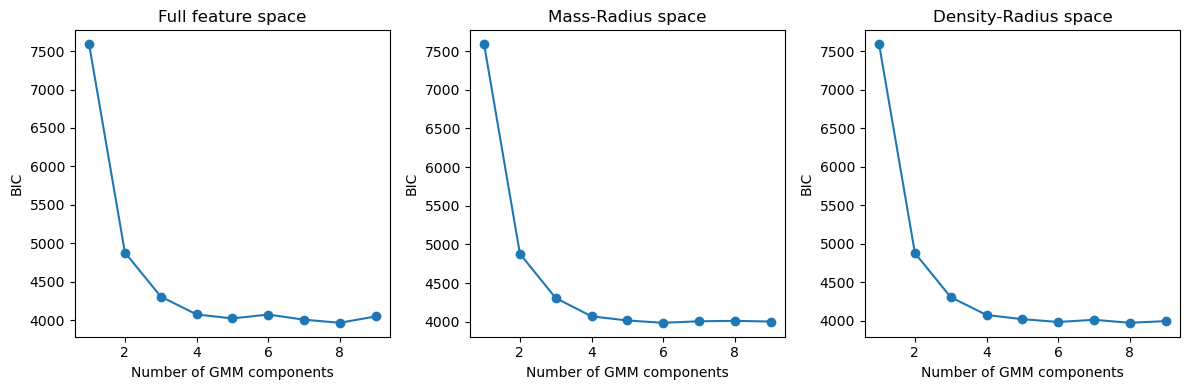

In [11]:
labels = ['Full feature space', 'Mass-Radius space', 'Density-Radius space']
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, ax in enumerate(axes):
    ax.plot(range(1,10), bics[i], marker='o')
    ax.set_title(labels[i])
    ax.set_xlabel('Number of GMM components')
    ax.set_ylabel('BIC')

plt.tight_layout()
plt.savefig('bic_comparison.png')
plt.show()

In [12]:
def delta_bic(bic):
    delta_bic = []
    for k in range(1,9):
        delta_bic.append(bic[k-1]-bic[k])
    return delta_bic


In [13]:
delta_bics = [delta_bic(b1), delta_bic(b2), delta_bic(b3)]

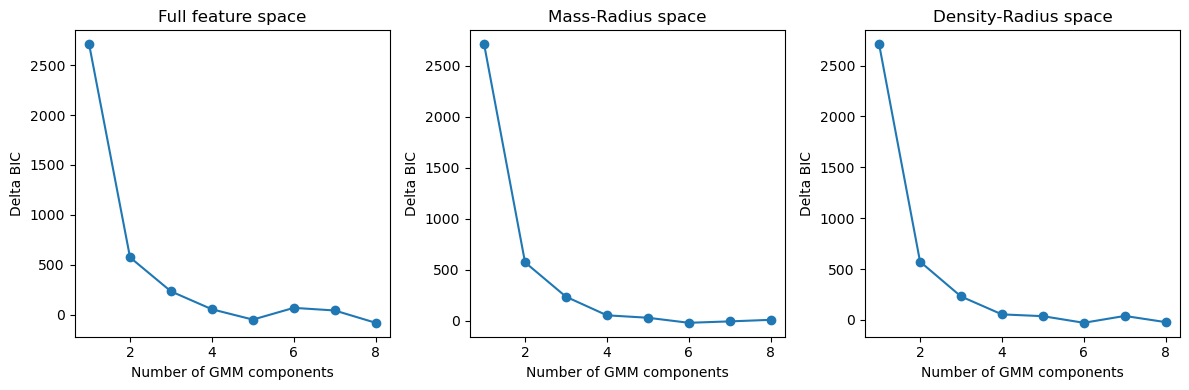

In [14]:
labels = ['Full feature space', 'Mass-Radius space', 'Density-Radius space']
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, ax in enumerate(axes):
    ax.plot(range(1,9), delta_bics[i], marker='o')
    ax.set_title(labels[i])
    ax.set_xlabel('Number of GMM components')
    ax.set_ylabel('Delta BIC')

plt.tight_layout()
plt.savefig('delta_bic_comparison.png')
plt.show()


In [15]:
X_train, X_test = train_test_split(log_data, test_size=0.01, random_state=42)
gmm_best = GaussianMixture(n_components=5, random_state=30)
gmm_best.fit(X_train)
y_train = gmm_best.predict(X_train)
y_test = gmm_best.predict(X_test)




In [22]:
planet_names  = ['Mercury','Venus','Earth','Mars','Jupiter','Saturn','Uranus','Neptune']
ss_logR = np.log10(ss_planets['radius'].values)
ss_logM = np.log10(ss_planets['mass'].values)
ss_logD = np.log10(ss_planets['bulk density'].values)
ss_logO = np.log10(ss_planets['orbital period'].values)

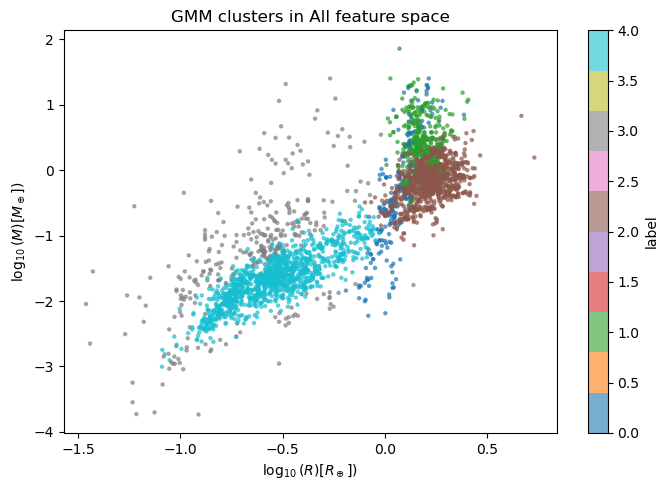

In [24]:

y_train_all = gmm_best.predict(log_data)

fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(log_data[:, 0], log_data[:, 1],
                     c=y_train_all, cmap='tab10', s=5, alpha=0.6)

ax.set_xlabel(r'$\log_{10}(R) [ R_\oplus])$')
ax.set_ylabel(r'$\log_{10}(M) [ M_\oplus])$')
ax.set_title('GMM clusters in All feature space')
plt.colorbar(scatter, ax=ax, label='label')
plt.tight_layout()
plt.savefig('gmm.png')
plt.show()

In [18]:

knn = KNeighborsClassifier(n_neighbors=300)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)


In [19]:
ss_vals = np.array([ss_logR, ss_logM, ss_logD, ss_logO])

X_ss = ss_vals.T

knn.predict(X_ss)

array([4, 0, 0, 4, 1, 1, 3, 3])

In [ ]:
#do accuracy test here

In [38]:
svm = SVC()
svm.fit(X_train, y_train)

#svm.predict(X_test)

svm.predict(X_ss)

array([0, 0, 0, 3, 0, 0, 0, 0])

In [37]:
gmm_best.predict(X_ss)

array([3, 0, 0, 3, 0, 0, 3, 3])